In [3]:
import sys
import pathlib      
import importlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
project_root = pathlib.Path.cwd().parent     
if project_root.as_posix() not in sys.path:   # avoid duplicates
    sys.path.insert(0, project_root.as_posix())
import toolbox.pipeline as tp
importlib.reload(tp)

import numpy as np
import matplotlib.pyplot as plt

# Deine Module importieren
from toolbox.pipeline.gabor import run, compute_pc, scale_colour_map
from toolbox.pipeline.postprocessing import get_nms_map, visualize_nms_process




In [4]:
# only used as an overlay
img = cv2.imread("gebiet_4_enhanced_contrast.tif")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
rgb
#plt.imshow(rgb)
#check rice distribution instead of mad 
#estimate it from faut free images

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[247, 178,  38],
        [244, 159,  36],
        [237, 129,  33],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[243, 144,  34],
        [237, 129,  33],
        [233, 115,  31],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[239, 137,  34],
        [235, 122,  32],
        [230, 108,  31],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [5]:
results = run(
    "gebiet_4_enhanced_contrast.tif",
    scales=[
        dict(sigma=2,  lambd=4),   # very fine — new
        dict(sigma=4,  lambd=16),  # fine
        dict(sigma=8,  lambd=64),  # medium
    ],
    gamma=0.2,
    step_deg=5,
)


Auto kernel size for sigma_max=8: (49, 49)


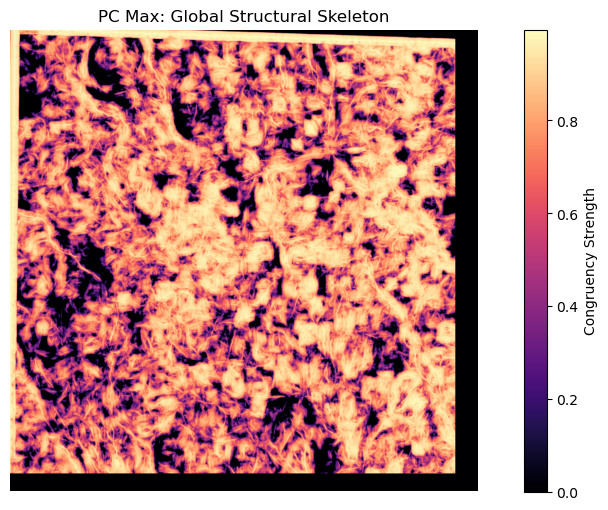

In [ ]:
# 1. PC_max (Das aggregierte Ergebnis über alle Richtungen)
plt.figure(figsize=(12, 6))
plt.imshow(pc_max, cmap='magma')
plt.title("PC Max: Global Structural Skeleton")
plt.colorbar(label='Congruency Strength')
plt.axis('off')
plt.show()



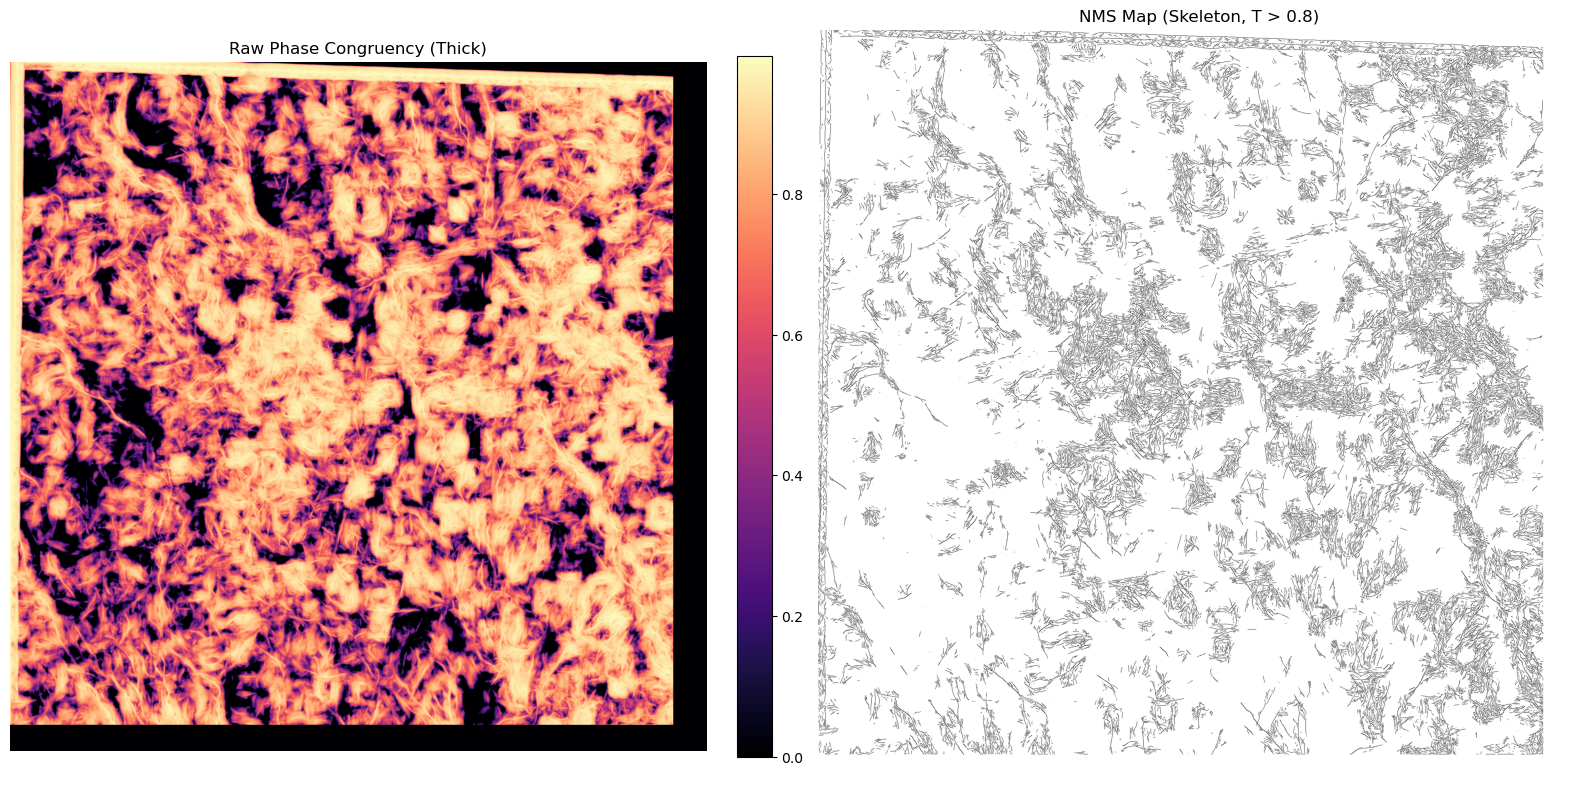

In [ ]:
nms_map = get_nms_map(pc_max, best_theta_idx, np.deg2rad(thetas_u))

# 4. Visualisierung des PoC
visualize_nms_process(pc_max, nms_map, threshold=0.8)